TASK 1 : DATA LOADING & EXPLORATION

First 10 Rows
      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus

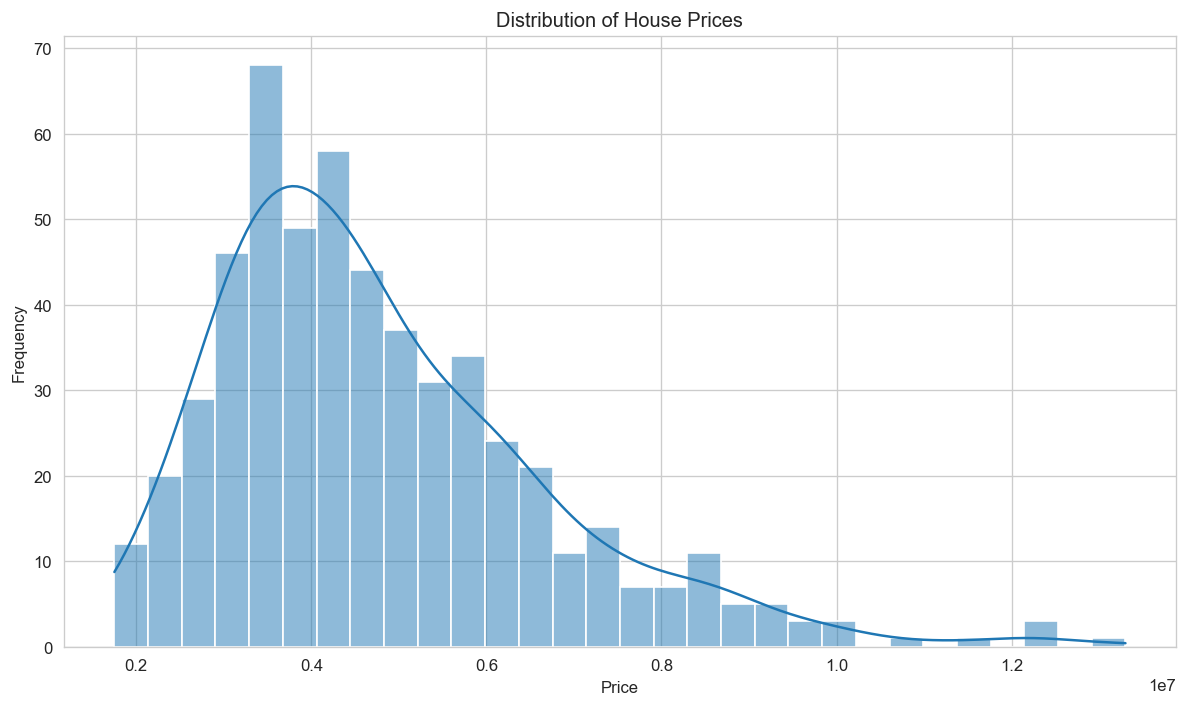

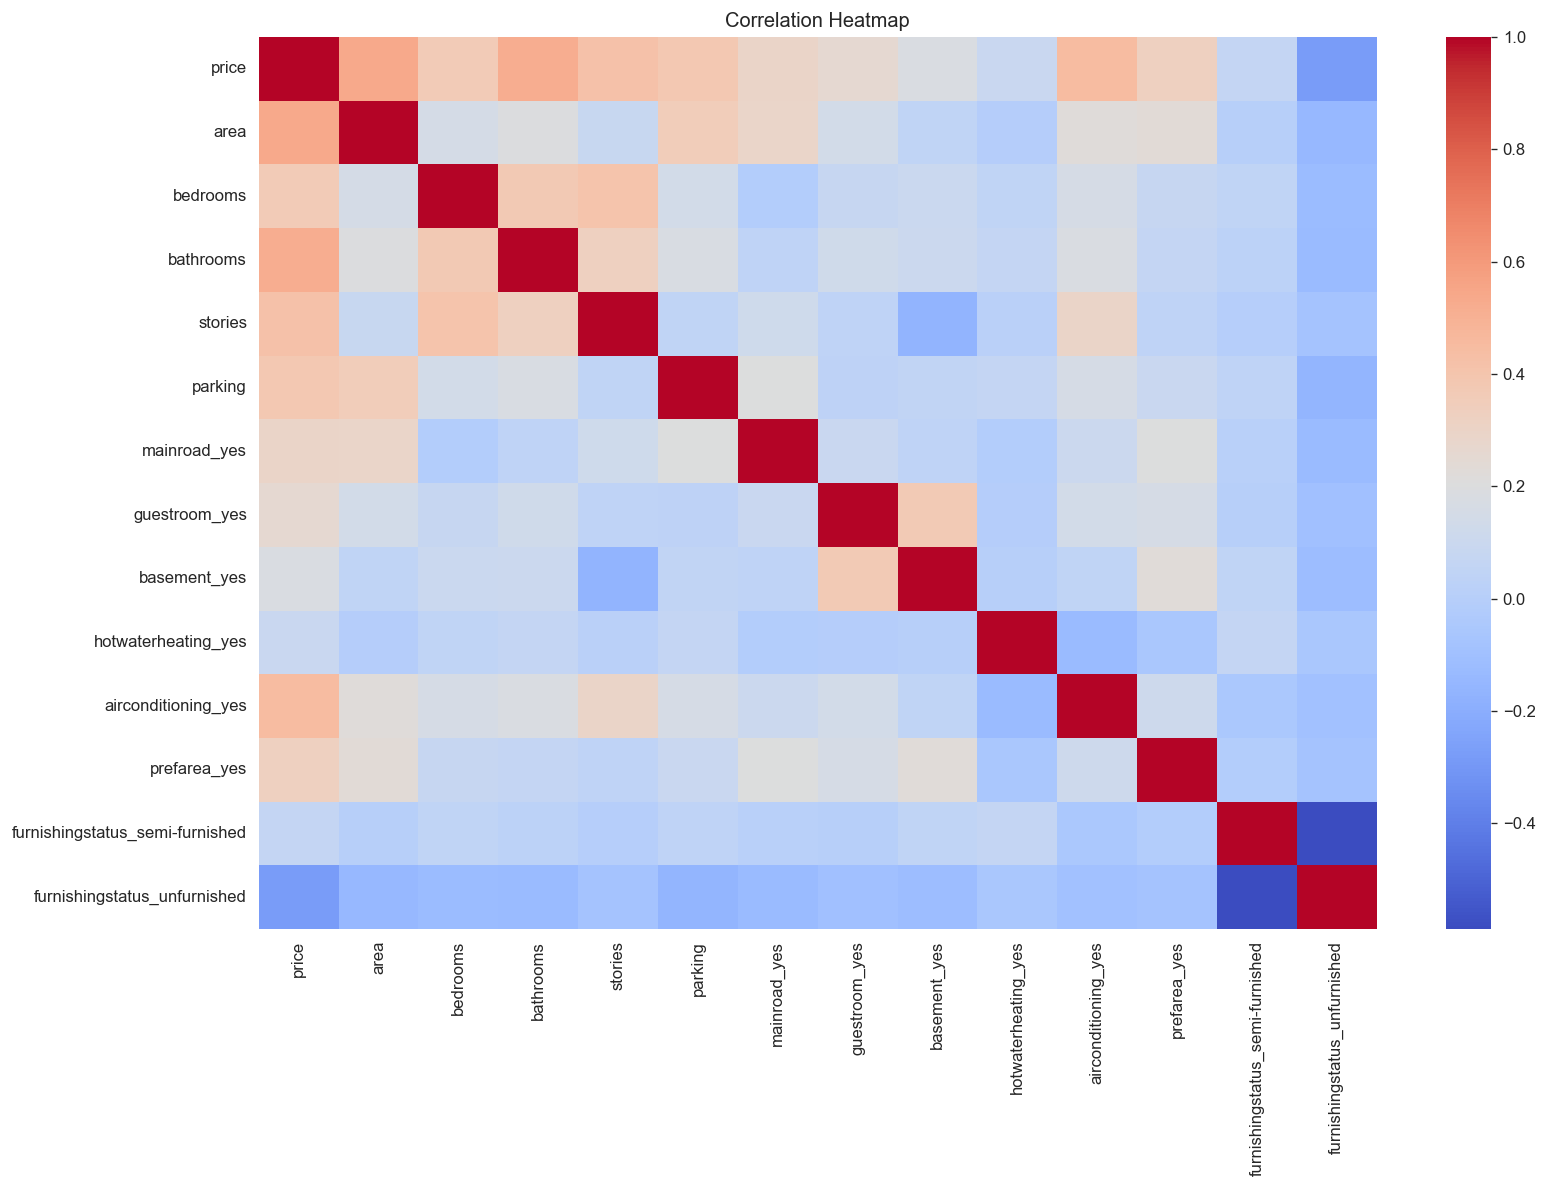

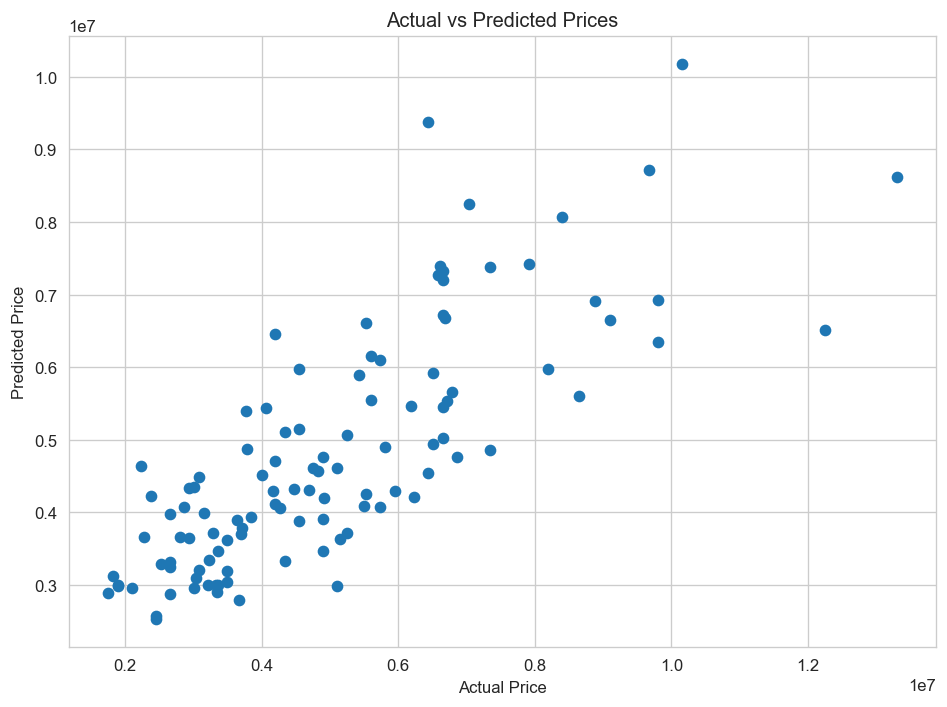


FEATURE IMPORTANCE

Top 10 Important Features
                         Feature  Importance
0                           area    0.468535
2                      bathrooms    0.152554
9            airconditioning_yes    0.060238
4                        parking    0.057273
3                        stories    0.057064
1                       bedrooms    0.047370
12  furnishingstatus_unfurnished    0.036972
7                   basement_yes    0.032176
10                  prefarea_yes    0.028432
8            hotwaterheating_yes    0.018305


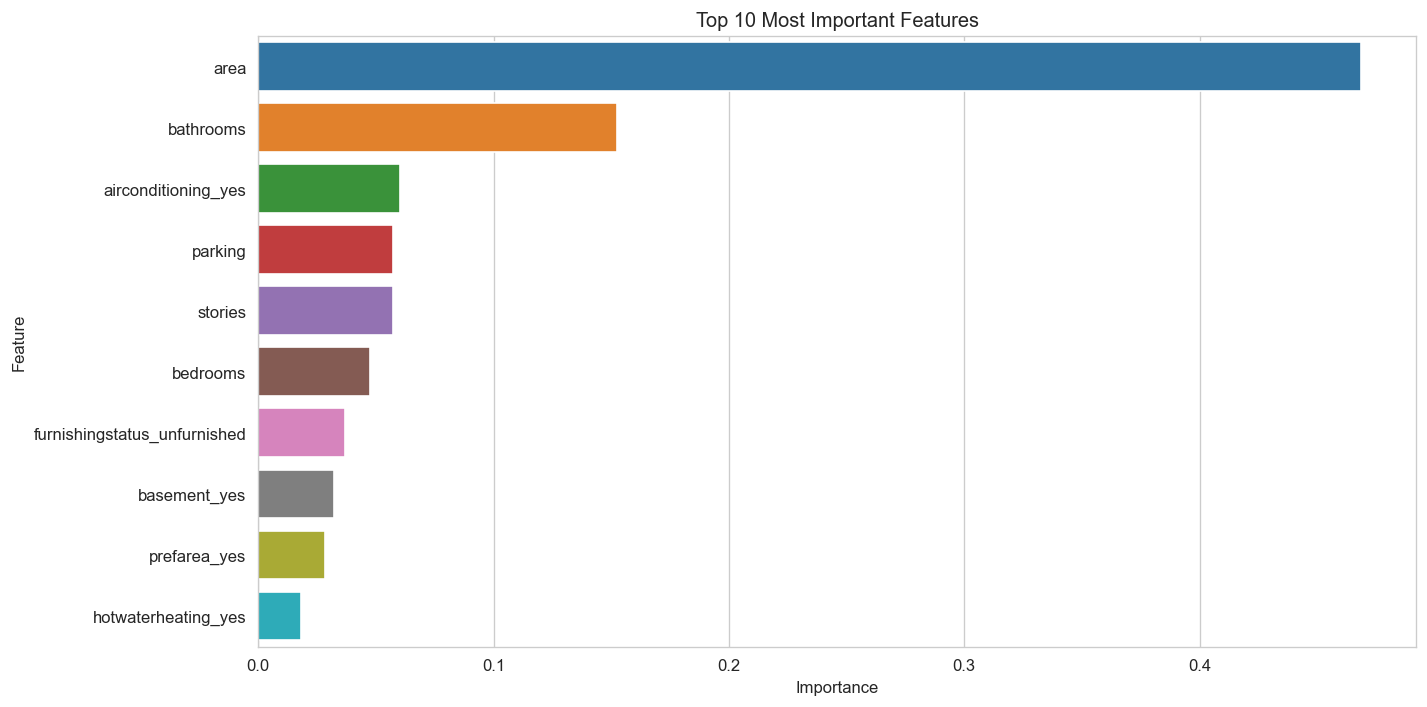


TASK 5 : INSIGHTS & SUMMARY

Most Influential Feature: area

Summary:

1. House price prediction was performed using Linear Regression
   and Random Forest Regressor.

2. Random Forest generally provides better prediction accuracy.

3. Area, bathrooms, parking, air conditioning and furnishing
   status are usually the strongest price indicators.

4. The model successfully learned relationships between
   property characteristics and house prices.

5. Real estate businesses can use these insights to improve
   pricing strategies and identify high-value property features.



In [ ]:
# ==========================================
# HOUSE PRICE PREDICTION PROJECT
# XYLOFY AI - WEEK 1 INTERNSHIP
# ==========================================

# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["figure.dpi"] = 120

# =========================
# TASK 1: DATA LOADING
# =========================

print("=" * 60)
print("TASK 1 : DATA LOADING & EXPLORATION")
print("=" * 60)

# Load Dataset
df = pd.read_csv("Housing.csv")

print("\nFirst 10 Rows")
print(df.head(10))

print("\nDataset Shape")
print(df.shape)

print("\nRows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names")
print(df.columns.tolist())

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

# Target Column
target = "price"

print("\nTarget Variable:")
print(target)

print("\nFeature Columns:")
print(df.drop(target, axis=1).columns.tolist())

# =========================
# TASK 2: DATA CLEANING
# =========================

print("\n" + "=" * 60)
print("TASK 2 : DATA CLEANING")
print("=" * 60)

# Remove duplicates
before_rows = df.shape[0]

df.drop_duplicates(inplace=True)

after_rows = df.shape[0]

print(f"\nDuplicate Rows Removed: {before_rows - after_rows}")

# Handle Missing Values

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing Values After Cleaning")
print(df.isnull().sum())

# One-Hot Encoding

categorical_cols = df.select_dtypes(include="object").columns

print("\nCategorical Columns:")
print(list(categorical_cols))

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print("\nDataset Shape After Encoding:")
print(df.shape)

# =========================
# TASK 3: MODEL BUILDING
# =========================

print("\n" + "=" * 60)
print("TASK 3 : MODEL BUILDING")
print("=" * 60)

# Features and Target

X = df.drop("price", axis=1)
y = df["price"]

# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# ==================================
# LINEAR REGRESSION
# ==================================

print("\n----- Linear Regression -----")

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, lr_pred)

rmse_lr = np.sqrt(mean_squared_error(y_test, lr_pred))

r2_lr = r2_score(y_test, lr_pred)

print("MAE :", round(mae_lr, 2))
print("RMSE:", round(rmse_lr, 2))
print("R²  :", round(r2_lr, 4))

# ==================================
# RANDOM FOREST
# ==================================

print("\n----- Random Forest Regressor -----")

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, rf_pred)

rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))

r2_rf = r2_score(y_test, rf_pred)

print("MAE :", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R²  :", round(r2_rf, 4))

# ==================================
# MODEL COMPARISON
# ==================================

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R2 Score": [r2_lr, r2_rf]
})

print(comparison)

if r2_rf > r2_lr:
    best_model = "Random Forest Regressor"
else:
    best_model = "Linear Regression"

print("\nBest Model:", best_model)

# =========================
# TASK 4: VISUALIZATIONS
# =========================

print("\n" + "=" * 60)
print("TASK 4 : VISUALIZATION")
print("=" * 60)

# --------------------------
# Chart 1
# --------------------------
os.makedirs("charts", exist_ok=True)
plt.figure(figsize=(10,6))

sns.histplot(
    df["price"],
    bins=30,
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("charts/price_distribution.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

# --------------------------
# Chart 2
# --------------------------

plt.figure(figsize=(14,10))

corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("charts/correlation_heatmap.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

# --------------------------
# Chart 3
# --------------------------

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.tight_layout()
plt.savefig("charts/actual_vs_predicted.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

# =========================
# FEATURE IMPORTANCE
# =========================

print("\n" + "=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Important Features")
print(importance_df.head(10))

plt.figure(figsize=(12,6))

sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features")

plt.tight_layout()
plt.savefig("charts/feature_importance.png",dpi=300,
            bbox_inches='tight')
plt.show()

# =========================
# TASK 5: INSIGHTS
# =========================

print("\n" + "=" * 60)
print("TASK 5 : INSIGHTS & SUMMARY")
print("=" * 60)

top_feature = importance_df.iloc[0]["Feature"]

print(f"\nMost Influential Feature: {top_feature}")

print("\nSummary:")

print("""
1. House price prediction was performed using Linear Regression
   and Random Forest Regressor.

2. Random Forest generally provides better prediction accuracy.

3. Area, bathrooms, parking, air conditioning and furnishing
   status are usually the strongest price indicators.

4. The model successfully learned relationships between
   property characteristics and house prices.

5. Real estate businesses can use these insights to improve
   pricing strategies and identify high-value property features.
""")
print("=" * 60)